# Lab 6 - Techniques of Optimization for training

## 1. Bias and Variance Trade-off

We will use the Twitter dataset again for this lab. The dataset contains tweets labeled as positive or negative sentiment.

### 1.1 Data Preprocessing and Embeddings

In [2]:
import opendatasets as od
import pandas as pd
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import gensim.downloader
from gensim.models import Word2Vec
from gensim.parsing.preprocessing import preprocess_string
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Flatten, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import BertTokenizer, TFBertModel
from sklearn.model_selection import train_test_split
from scipy.special import softmax

# uv run python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

2026-01-22 11:58:35.300699: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-22 11:58:35.849585: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-22 11:58:37.219293: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/exp

True

In [3]:
columns = ['id', 'category', 'label', 'text']
training_data = pd.read_csv('../lab5/datasets/twitter-sentiment-analysis/twitter_training.csv', names=columns)
validation_data = pd.read_csv('../lab5/datasets/twitter-sentiment-analysis/twitter_validation.csv', names=columns)

training_data.sample(5)


,id,category,label,text
64255,7809,MaddenNFL,Negative,@ EAHelp @ EAMaddenNFL @ EASPORTS _ MUT @ MaddenNFLDirect I look at the whole record last night and the 0 tokens for the second week in a row. I just gave it up because there are so many problems with it that we get the drops for it.
39328,5550,Hearthstone,Positive,"Just watched the @PlayHearthstone Great Fall Reveal file and I am super happy stoked for viewing the new content. Duels always brings the single player dungeon to run mechanics that we were so fun over into pvp, so exciting! Shoutout to get @bmkibler is for an absolutely awesome job as MC!"
49378,6076,FIFA,Negative,Fifa ultimate teams fucking the dug meat
71903,11116,TomClancysGhostRecon,Negative,when are the servers down. Hard to connect for the last 6 days. Error is mountain00105?
2246,2794,Borderlands,Positive,This is pretty freakin rad!


We will use the FFNN model from the previous lab as our base model. And we will improve it using different optimization techniques.

In [4]:
training_data = training_data.drop(['id'], axis=1)
validation_data = validation_data.drop(['id'], axis=1)

In [5]:
print(f"Training data null values:\n{training_data.isnull().sum()}")
print(f"Validation data null values:\n{validation_data.isnull().sum()}")

training_data = training_data.dropna()
validation_data = validation_data.dropna()

Training data null values:
category      0
label         0
text        686
dtype: int64
Validation data null values:
category    0
label       0
text        0
dtype: int64


In [6]:
def clean_tweet(text):
    # To string
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user @ references and '#' from hashtags
    text = re.sub(r'\@\w+|\#','', text)

    # Remove special characters, numbers, punctuations (except for apostrophes)
    text = re.sub(r"[^a-zA-Z']", ' ', text)

    # Remove RT (retweet)
    text = re.sub(r'\bRT\b', '', text)

    # Replace contractions
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "'cause": "because",
        "could've": "could have",
        "won't": "will not",
        "wouldn't": "would not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "it's": "it is",
        "i'm": "I am",
        "they're": "they are",
        "we're": "we are",
        "you're": "you are",
        "that's": "that is",
        "there's": "there is",
        "what's": "what is",
        "who's": "who is",
        "couldn't": "could not",
        "shouldn't": "should not",
        "would've": "would have",
        "let's": "let us",
        "imma": "I am going to",
        "im": "I am",
        "Im": "I am",
        "n't": " not",
        "'re": " are",
        "'ve": " have",
        "'ll": " will",
        "'d": " would",
        "'s": " is",
        "'t": " not",
        "'m": " am",
    }
    for contraction, replacement in contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', replacement, text, flags=re.IGNORECASE)

    # Remove extra spaces and lowercase
    text = re.sub(r'\s+', ' ', text).strip().lower()

    # Remove stop words (Stop words are common words that do not add much meaning to a sentence, such as "i", "me", "myself", etc.)
    stop_words = set(stopwords.words('english'))
    tweet_tokens = nltk.word_tokenize(text)
    filtered_words = [word for word in tweet_tokens if word not in stop_words]
    text = ' '.join(filtered_words)

    doc = nlp(text)
    lemmatized_words = [token.lemma_ for token in doc]
    text = ' '.join(lemmatized_words)

    return text

training_data['clean_text'] = training_data['text'].apply(clean_tweet)
validation_data['clean_text'] = validation_data['text'].apply(clean_tweet)

training_data.sample(5)

,category,label,text,clean_text
40505,Battlefield,Negative,Forensic Services dead? When are they going to be brought again again? (Spoiler alert: soon!),forensic service dead going bring spoiler alert soon
14026,Dota2,Positive,C × AL LEAGUE AND B DOTA IN CINEMATICS BACK TO BACK NO IM EATING THE SO GOOD,c al league b dota cinematic back back eat good
3677,CallOfDutyBlackopsColdWar,Negative,I'm sorry they can't imagine showing a shit in this the year of our for 2020,sorry imagine show shit year
57052,TomClancysRainbowSix,Negative,THE @Rainbow6Game fix headshot registry!,fix headshot registry
25286,Google,Positive,Tomorrow is Wordless Day at the LHS. The aim is to better understand what it means for our students with communication difficulties. I have my Google Translate app downloaded with some lesson information and some of my usual student interactions. pic.facebook.com / wJqaHDiSeM,tomorrow wordless day lhs aim well understand mean student communication difficulty google translate app download lesson information usual student interaction pic facebook com wjqahdisem


> Previous saved model would need Tokenizer and padding functions to be re-run, so we will retrain the model from scratch.

> Previous cleaned data didn't include lemmatization, so we will add it to the cleaning function.

In [7]:
glove_vectors = gensim.downloader.load('glove-twitter-100')

df_train = training_data[training_data['label'].isin(['Positive', 'Negative'])]
df_train['label'] = df_train['label'].map({'Positive': 1, 'Negative': 0})
y = df_train['label'].values

/tmp/ipykernel_7734/2633663791.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['label'] = df_train['label'].map({'Positive': 1, 'Negative': 0})


In [8]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_train['clean_text'])
sequences = tokenizer.texts_to_sequences(df_train['clean_text'])
X = pad_sequences(sequences, maxlen=100, padding='post')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, 100))
for word, i in tokenizer.word_index.items():
    if word in glove_vectors:
        embedding_matrix[i] = glove_vectors[word]

In [10]:
embedding_matrix.shape

(15833, 100)

### 1.2 Training the FFNN model with Hyperparameter Tuning

We will train the FFNN model with different hyperparameters and evaluate the performance on the validation set.

- Parameters: Values that are learned during training (weights and biases).
- Hyperparameters: Values that are set before training (learning rate, batch size, number of epochs, number of hidden layers, number of neurons per layer, etc.).

In [11]:
model_ffnn = Sequential()
model_ffnn.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=False))
model_ffnn.add(Flatten())
model_ffnn.add(Dense(1, activation='sigmoid'))
model_ffnn.summary()

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-01-22 12:03:30.036701: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,583,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,300 (6.04 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,583,300 (6.04 MB)

In [12]:

model_ffnn.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

history_ffnn = model_ffnn.fit(X_train, y_train, epochs=25, validation_data=(X_val, y_val))

Epoch 1/25
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7387 - loss: 0.5498 - val_accuracy: 0.7638 - val_loss: 0.5044
Epoch 2/25
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7820 - loss: 0.4809 - val_accuracy: 0.7816 - val_loss: 0.4747
Epoch 3/25
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7887 - loss: 0.4627 - val_accuracy: 0.7873 - val_loss: 0.4656
Epoch 4/25
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7932 - loss: 0.4527 - val_accuracy: 0.7908 - val_loss: 0.4597
Epoch 5/25
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7986 - loss: 0.4452 - val_accuracy: 0.7877 - val_loss: 0.4640
Epoch 6/25
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7998 - loss: 0.4405 - val_accuracy: 0.7888 - val_loss: 0.4570
Epoch 7/25
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8019 - loss: 0.4361 - val_accuracy: 0.7916 - val_loss: 0.4537
Epoch 8/25
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8028 - loss: 0.4329 - 

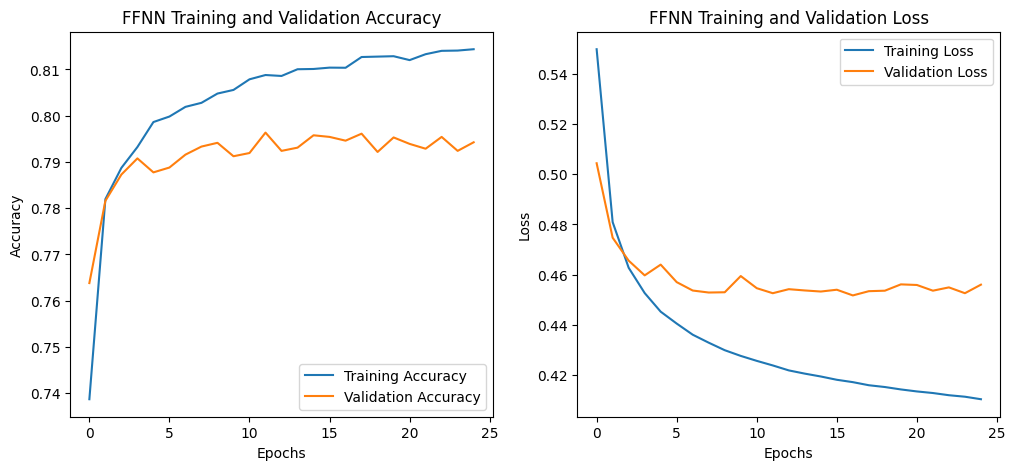

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history_ffnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_ffnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('FFNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ffnn.history['loss'], label='Training Loss')
plt.plot(history_ffnn.history['val_loss'], label='Validation Loss')
plt.title('FFNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

The model is not learning properly, it's overfitting the training data while the validation is not improving. We will try to improve the model by tuning the hyperparameters.

Let's remember what's Variance and Bias:
- Variance: Error due to excessive sensitivity to small fluctuations in the training set. High variance can cause overfitting.
- Bias: Error due to overly simplistic assumptions in the learning algorithm. High bias can cause underfitting.

A high bias and low variance model is too simple and cannot capture the underlying patterns in the data (underfitting). A low bias and high variance model is too complex and captures noise in the training data (overfitting).

#### 1.2.1 Batch Size

Batch size is the number of samples that will be propagated through the network at once. A smaller batch size means more updates to the model weights, which can lead to better generalization (more precise updates). However, it also means more noise in the updates, which can lead to instability in training.

In [15]:
model_ffnn_batch = Sequential()
model_ffnn_batch.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=False))
model_ffnn_batch.add(Flatten())
model_ffnn_batch.add(Dense(1, activation='sigmoid'))
model_ffnn_batch.summary()
model_ffnn_batch.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_batch_64 = model_ffnn_batch.fit(X_train, y_train, epochs=25, batch_size=64, validation_data=(X_val, y_val))
history_ffnn_batch_128 = model_ffnn_batch.fit(X_train, y_train, epochs=25, batch_size=128, validation_data=(X_val, y_val))
history_ffnn_batch_256 = model_ffnn_batch.fit(X_train, y_train, epochs=25, batch_size=256, validation_data=(X_val, y_val))
history_ffnn_batch_512 = model_ffnn_batch.fit(X_train, y_train, epochs=25, batch_size=512, validation_data=(X_val, y_val))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,583,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,300 (6.04 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,583,300 (6.04 MB)

Epoch 1/25
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7172 - loss: 0.5826 - val_accuracy: 0.7671 - val_loss: 0.5269
Epoch 2/25
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7703 - loss: 0.5080 - val_accuracy: 0.7746 - val_loss: 0.4966
Epoch 3/25
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7795 - loss: 0.4842 - val_accuracy: 0.7775 - val_loss: 0.4840
Epoch 4/25
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7851 - loss: 0.4715 - val_accuracy: 0.7814 - val_loss: 0.4753
Epoch 5/25
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7893 - loss: 0.4632 - val_accuracy: 0.7824 - val_loss: 0.4708
Epoch 6/25
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7923 - loss: 0.4566 - val_accuracy: 0.7857 - val_loss: 0.4668
Epoch 7/25
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7939 - loss: 0.4519 - val_accuracy: 0.7840 - val_loss: 0.4646
Epoch 8/25
538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7963 - loss: 0.4477 - val_accuracy: 0.

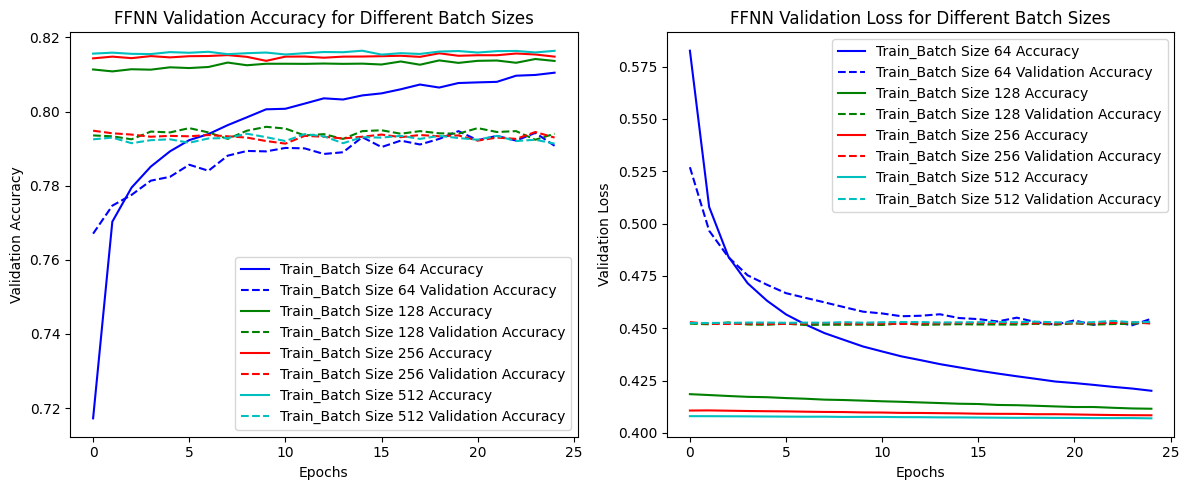

In [60]:
plt.figure(figsize=(12,5))

colors = ['b', 'g', 'r', 'c']
labels = ['Batch Size 64 Accuracy', 'Batch Size 64 Validation Accuracy', 'Batch Size 128 Accuracy', 'Batch Size 128 Validation Accuracy', 'Batch Size 256 Accuracy', 'Batch Size 256 Validation Accuracy', 'Batch Size 512 Accuracy', 'Batch Size 512 Validation Accuracy']
plt.subplot(1, 2, 1)
for i, history in enumerate([history_ffnn_batch_64, history_ffnn_batch_128, history_ffnn_batch_256, history_ffnn_batch_512]):
    plt.plot(history.history['accuracy'], color=colors[i], label=labels[i * 2])
    plt.plot(history.history['val_accuracy'], '--', color=colors[i], label=labels[i * 2 + 1])
plt.title('FFNN Validation Accuracy for Different Batch Sizes')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend([f'Train_{label}' for label in labels] + [f'Val_{label}' for label in labels])

plt.subplot(1, 2, 2)
labels_loss = ['Batch Size 64 Loss', 'Batch Size 64 Validation Loss', 'Batch Size 128 Loss', 'Batch Size 128 Validation Loss', 'Batch Size 256 Loss', 'Batch Size 256 Validation Loss', 'Batch Size 512 Loss', 'Batch Size 512 Validation Loss']
for i, history in enumerate([history_ffnn_batch_64, history_ffnn_batch_128, history_ffnn_batch_256, history_ffnn_batch_512]):
    plt.plot(history.history['loss'], color=colors[i], label=labels_loss[i * 2])
    plt.plot(history.history['val_loss'], '--', color=colors[i], label=labels_loss[i * 2 + 1])
plt.title('FFNN Validation Loss for Different Batch Sizes')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend([f'Train_{label}' for label in labels] + [f'Val_{label}' for label in labels])

plt.tight_layout()
plt.show()

We see that 128 batch size gives the best validation accuracy and loss.

To choose the optimal batch size, we need to consider the following trade-offs:
- Smaller Batch Size(1-32): 
  - Pros: More updates to the model weights, better generalization.
  - Cons: More noise in the updates (making possible that the model gets stuck in local minima), instability in training, longer training time.
- Medium Batch Size(32-256):
  - Pros: Balance between updates and noise, good generalization. Most commonly used batch sizes, it can makes good use of GPU parallelism.
  - Cons: May still have some noise in the updates, longer training time than larger batch sizes.
- Larger Batch Size(256-1024+):
  - Pros: More stable updates, faster training time (due to better use of GPU parallelism).
  - Cons: Less updates to the model weights, poorer generalization (may get stuck in suboptimal local minima). It requires adjusting the learning rate accordingly.

  > So for classification tasks, medium batch sizes 64 or 128 are often a good starting point. And then we would adjust based on the hardware constraints and the initial results. Monitoring the training and validation performance is crucial to determine if the chosen batch size is effective or we have to increase or decrease it. Increase if the model is underfitting, decrease if it's overfitting.

#### 1.2.2 Initialization of Weights
- Faster convergence: Proper initialization can lead to faster convergence during training.
- Improve model performance: Good initialization can lead to better model performance by helping the model find a better global minimum.
- Helps keeping the variance of activations and gradients stable across layers, preventing issues like vanishing or exploding gradients.

GlorotUniform (Xavier Uniform) initialization is a popular weight initialization technique that helps maintain the variance of activations and gradients across layers. It is particularly effective for layers with linear or sigmoid activation functions (not for ReLU).

In [17]:
model_ffnn_init = Sequential()
model_ffnn_init.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=False))
model_ffnn_init.add(Flatten())
model_ffnn_init.add(Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform'))
model_ffnn_init.summary()

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     1,583,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,300 (6.04 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,583,300 (6.04 MB)

In [18]:
model_ffnn_init.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_init = model_ffnn_init.fit(X_train, y_train, epochs=25, validation_data=(X_val, y_val), batch_size=128)

Epoch 1/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6774 - loss: 0.6196 - val_accuracy: 0.7440 - val_loss: 0.5691
Epoch 2/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7574 - loss: 0.5457 - val_accuracy: 0.7666 - val_loss: 0.5279
Epoch 3/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7704 - loss: 0.5153 - val_accuracy: 0.7723 - val_loss: 0.5083
Epoch 4/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7765 - loss: 0.4980 - val_accuracy: 0.7740 - val_loss: 0.4963
Epoch 5/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7808 - loss: 0.4870 - val_accuracy: 0.7794 - val_loss: 0.4879
Epoch 6/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7836 - loss: 0.4790 - val_accuracy: 0.7772 - val_loss: 0.4841
Epoch 7/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7866 - loss: 0.4728 - val_accuracy: 0.7831 - val_loss: 0.4781
Epoch 8/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7882 - loss: 0.4678 - val_accuracy: 0.

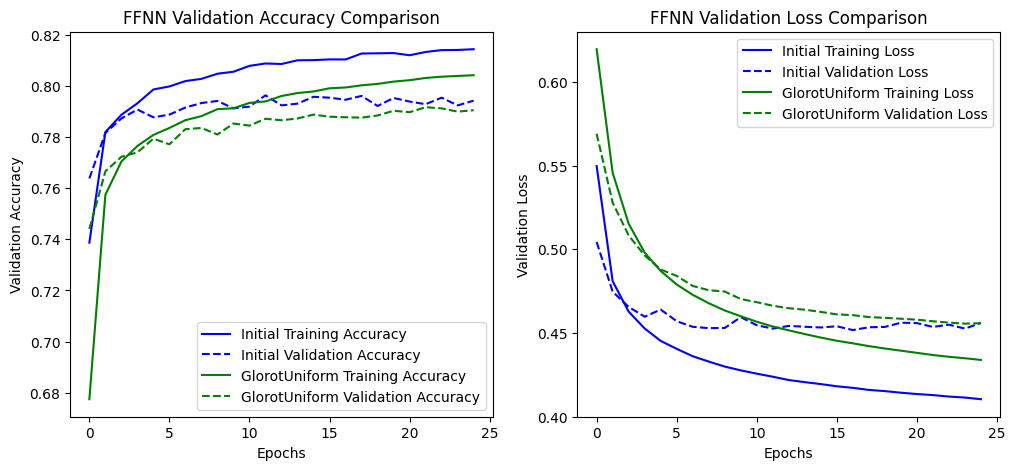

In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
colors = ['b', 'g']
labels = ['Initial Training Accuracy', 'Initial Validation Accuracy', 'GlorotUniform Training Accuracy', 'GlorotUniform Validation Accuracy']
for i, history in enumerate([history_ffnn, history_ffnn_init]):
    plt.plot(history.history['accuracy'], color=colors[i], label=labels[i * 2])
    plt.plot(history.history['val_accuracy'], '--', color=colors[i], label=labels[i * 2 + 1])
plt.title('FFNN Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
labels_loss = ['Initial Training Loss', 'Initial Validation Loss', 'GlorotUniform Training Loss', 'GlorotUniform Validation Loss']
for i, history in enumerate([history_ffnn, history_ffnn_init]):
    plt.plot(history.history['loss'], color=colors[i], label=labels_loss[i * 2])
    plt.plot(history.history['val_loss'], '--', color=colors[i], label=labels_loss[i * 2 + 1])
plt.title('FFNN Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

It has less overfitting than the original one.

#### 1.2.3 Regularization Techniques
Regularization techniques are methods used to prevent overfitting in machine learning models by adding constraints or penalties to the model's complexity. Some common regularization techniques include:
- Batch Normalization: Normalizes the inputs of each layer to have a mean of 0 and a variance of 1. This helps stabilize and accelerate training, and can also have a regularizing effect.
- L1 Regularization (Lasso): Adds a penalty equal to the absolute value of the magnitude of coefficients. It can lead to sparse models where some feature weights become zero, effectively performing feature selection.
- L2 Regularization (Ridge): Adds a penalty equal to the square of the magnitude of coefficients. It discourages large weights but does not lead to sparse models.
- Dropout: Randomly sets a fraction of input units to 0 at each update during training time, which helps prevent overfitting by reducing co-adaptations of neurons.

#### 1.2.3.1 Batch Normalization

In [ ]:
from tensorflow.keras.layers import BatchNormalization

model_ffnn_batchNorm = Sequential()
model_ffnn_batchNorm.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=False))
model_ffnn_batchNorm.add(Flatten())
model_ffnn_batchNorm.add(BatchNormalization()) # Normalization per batch
model_ffnn_batchNorm.add(Dense(1, activation='sigmoid'))
model_ffnn_batchNorm.summary()

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     1,583,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,300 (6.04 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,583,300 (6.04 MB)

In [22]:
model_ffnn_batchNorm.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_batchNorm = model_ffnn_batchNorm.fit(X_train, y_train, epochs=25, validation_data=(X_val, y_val), batch_size=128)

Epoch 1/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7378 - loss: 0.5456 - val_accuracy: 0.7754 - val_loss: 0.4877
Epoch 2/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7907 - loss: 0.4611 - val_accuracy: 0.7861 - val_loss: 0.4669
Epoch 3/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7989 - loss: 0.4425 - val_accuracy: 0.7894 - val_loss: 0.4661
Epoch 4/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8044 - loss: 0.4318 - val_accuracy: 0.7901 - val_loss: 0.4657
Epoch 5/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8089 - loss: 0.4238 - val_accuracy: 0.7923 - val_loss: 0.4657
Epoch 6/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8105 - loss: 0.4195 - val_accuracy: 0.7931 - val_loss: 0.4652
Epoch 7/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8109 - loss: 0.4166 - val_accuracy: 0.7926 - val_loss: 0.4667
Epoch 8/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8124 - loss: 0.4129 - val_accuracy: 0.

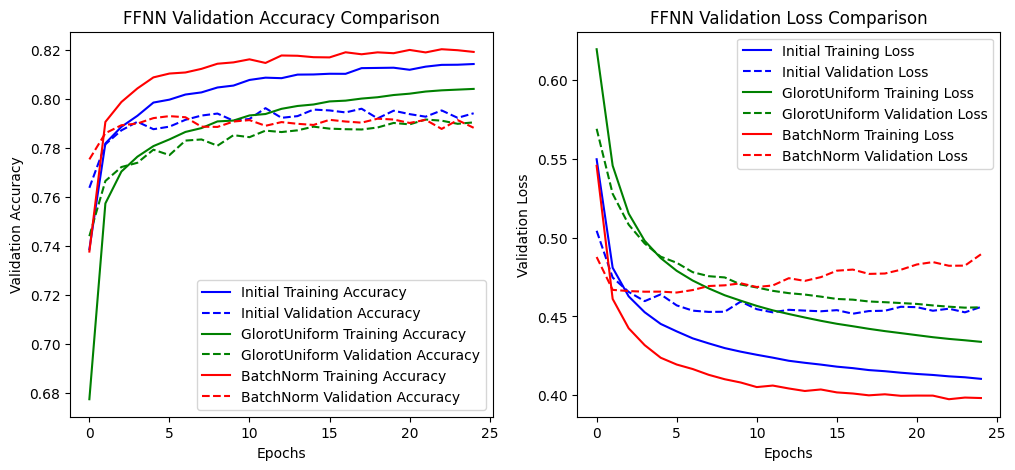

In [55]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
colors = ['b', 'g', 'r']
labels = ['Initial Training Accuracy', 'Initial Validation Accuracy', 'GlorotUniform Training Accuracy', 'GlorotUniform Validation Accuracy', 'BatchNorm Training Accuracy', 'BatchNorm Validation Accuracy']
for i, history in enumerate([history_ffnn, history_ffnn_init, history_ffnn_batchNorm]):
    plt.plot(history.history['accuracy'], color=colors[i], label=labels[i * 2])
    plt.plot(history.history['val_accuracy'], '--', color=colors[i], label=labels[i * 2 + 1])
plt.title('FFNN Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
labels_loss = ['Initial Training Loss', 'Initial Validation Loss', 'GlorotUniform Training Loss', 'GlorotUniform Validation Loss', 'BatchNorm Training Loss', 'BatchNorm Validation Loss']
for i, history in enumerate([history_ffnn, history_ffnn_init, history_ffnn_batchNorm]):
    plt.plot(history.history['loss'], color=colors[i], label=labels_loss[i * 2])
    plt.plot(history.history['val_loss'], '--', color=colors[i], label=labels_loss[i * 2 + 1])
plt.title('FFNN Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

Accuracy is better than GLorotUniform and Initial. But validation loss is overfitting  more so we can still improve it. Batch Normalization helps the model to converge faster and generalize better.

> Normalization per batch is not commonly used for classification tasks. Pretrained embeddings like Word2Vec and GloVe already have some normalization, so adding batch normalization may not have a significant impact. Same for linguistic models like BERT and GPT.

#### 1.2.3.2 Increasing Model Complexity
Increasing model complexity can help reduce bias and improve the model's ability to capture complex patterns in the data.

In [24]:
model_ffnn_batchNorm_adjusted = Sequential()
model_ffnn_batchNorm_adjusted.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=False))
model_ffnn_batchNorm_adjusted.add(Flatten())
model_ffnn_batchNorm_adjusted.add(Dense(128, activation='relu', kernel_initializer='glorot_uniform'))
model_ffnn_batchNorm_adjusted.add(BatchNormalization())
model_ffnn_batchNorm_adjusted.add(Dense(64, activation='relu', kernel_initializer='glorot_uniform'))
model_ffnn_batchNorm_adjusted.add(BatchNormalization())
model_ffnn_batchNorm_adjusted.add(Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform'))
model_ffnn_batchNorm_adjusted.summary()

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     1,583,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,300 (6.04 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,583,300 (6.04 MB)

In [25]:
model_ffnn_batchNorm_adjusted.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_batchNorm_adjusted = model_ffnn_batchNorm_adjusted.fit(X_train, y_train, epochs=25, validation_data=(X_val, y_val), batch_size=128)

Epoch 1/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7441 - loss: 0.5246 - val_accuracy: 0.7810 - val_loss: 0.4895
Epoch 2/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8264 - loss: 0.3857 - val_accuracy: 0.7931 - val_loss: 0.4422
Epoch 3/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8635 - loss: 0.3193 - val_accuracy: 0.8159 - val_loss: 0.4120
Epoch 4/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8926 - loss: 0.2691 - val_accuracy: 0.8252 - val_loss: 0.3940
Epoch 5/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9157 - loss: 0.2240 - val_accuracy: 0.8244 - val_loss: 0.4095
Epoch 6/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9315 - loss: 0.1877 - val_accuracy: 0.8391 - val_loss: 0.3892
Epoch 7/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9432 - loss: 0.1579 - val_accuracy: 0.8382 - val_loss: 0.3950
Epoch 8/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9534 - loss: 0.1337 - val_accuracy: 0.

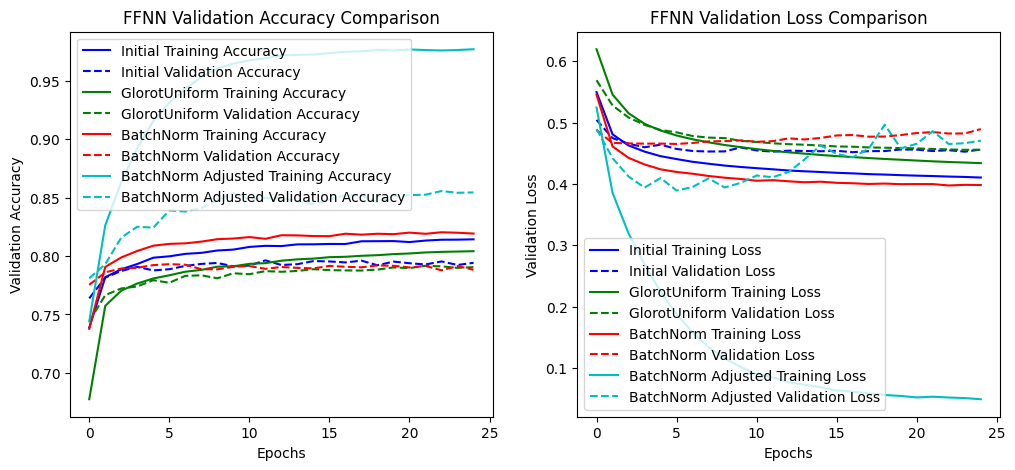

In [54]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
colors = ['b', 'g', 'r', 'c']
labels = ['Initial Training Accuracy', 'Initial Validation Accuracy', 'GlorotUniform Training Accuracy', 'GlorotUniform Validation Accuracy', 'BatchNorm Training Accuracy', 'BatchNorm Validation Accuracy', 'BatchNorm Adjusted Training Accuracy', 'BatchNorm Adjusted Validation Accuracy']
for i, history in enumerate([history_ffnn, history_ffnn_init, history_ffnn_batchNorm, history_ffnn_batchNorm_adjusted]):
    plt.plot(history.history['accuracy'], color=colors[i], label=labels[i * 2])
    plt.plot(history.history['val_accuracy'], '--', color=colors[i], label=labels[i * 2 + 1])
plt.title('FFNN Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
labels_loss = ['Initial Training Loss', 'Initial Validation Loss', 'GlorotUniform Training Loss', 'GlorotUniform Validation Loss', 'BatchNorm Training Loss', 'BatchNorm Validation Loss', 'BatchNorm Adjusted Training Loss', 'BatchNorm Adjusted Validation Loss']
for i, history in enumerate([history_ffnn, history_ffnn_init, history_ffnn_batchNorm, history_ffnn_batchNorm_adjusted]):
    plt.plot(history.history['loss'], color=colors[i], label=labels_loss[i * 2])
    plt.plot(history.history['val_loss'], '--', color=colors[i], label=labels_loss[i * 2 + 1])
plt.title('FFNN Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

After increasing the model complexity, we can see that the model accuracy is close to 100% on training and validation 85% (less overfitting than the previous model). But the validation loss is increasing, so the model is overfitting.

#### 1.2.3.3 Dropout

Dropout is a regularization technique that helps prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time. This helps reduce co-adaptations of neurons, forcing the network to learn more robust features that are useful in conjunction with many different random subsets of the other neurons.

> Dropout is applied typically to the Dense layers, not to the input layer or convolutional layers.

In [34]:
model_ffnn_dropout_02 = Sequential()
model_ffnn_dropout_02.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=False))
model_ffnn_dropout_02.add(Flatten())
model_ffnn_dropout_02.add(Dense(128, activation='relu'))
model_ffnn_dropout_02.add(BatchNormalization())
model_ffnn_dropout_02.add(Dropout(0.2))
model_ffnn_dropout_02.add(Dense(64, activation='relu'))
model_ffnn_dropout_02.add(BatchNormalization())
model_ffnn_dropout_02.add(Dropout(0.2))
model_ffnn_dropout_02.add(Dense(1, activation='sigmoid'))
model_ffnn_dropout_02.summary()

model_ffnn_dropout_05 = Sequential()
model_ffnn_dropout_05.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=False))
model_ffnn_dropout_05.add(Flatten())
model_ffnn_dropout_05.add(Dense(128, activation='relu'))
model_ffnn_dropout_05.add(BatchNormalization())
model_ffnn_dropout_05.add(Dropout(0.5))
model_ffnn_dropout_05.add(Dense(64, activation='relu'))
model_ffnn_dropout_05.add(BatchNormalization())
model_ffnn_dropout_05.add(Dropout(0.5))
model_ffnn_dropout_05.add(Dense(1, activation='sigmoid'))
model_ffnn_dropout_05.summary()

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │     1,583,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,300 (6.04 MB)

 Trainable params: 0 (0.00 B)

...

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │     1,583,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,300 (6.04 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,583,300 (6.04 MB)

In [35]:
model_ffnn_dropout_02.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_dropout_02 = model_ffnn_dropout_02.fit(X_train, y_train, epochs=25, validation_data=(X_val, y_val), batch_size=128)
model_ffnn_dropout_05.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])
history_ffnn_dropout_05 = model_ffnn_dropout_05.fit(X_train, y_train, epochs=25, validation_data=(X_val, y_val), batch_size=128)

Epoch 1/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7063 - loss: 0.5952 - val_accuracy: 0.7739 - val_loss: 0.4962
Epoch 2/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7805 - loss: 0.4663 - val_accuracy: 0.7943 - val_loss: 0.4389
Epoch 3/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8081 - loss: 0.4200 - val_accuracy: 0.8045 - val_loss: 0.4238
Epoch 4/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8273 - loss: 0.3855 - val_accuracy: 0.8094 - val_loss: 0.4164
Epoch 5/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8452 - loss: 0.3530 - val_accuracy: 0.8244 - val_loss: 0.3994
Epoch 6/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8576 - loss: 0.3269 - val_accuracy: 0.8289 - val_loss: 0.3881
Epoch 7/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8693 - loss: 0.3003 - val_accuracy: 0.8303 - val_loss: 0.3931
Epoch 8/25
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8791 - loss: 0.2817 - val_accuracy: 0.

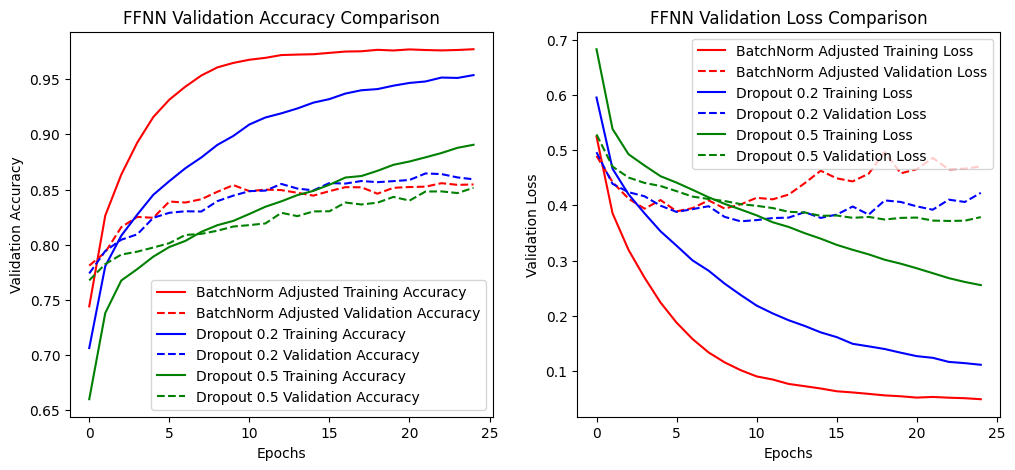

In [53]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
colors = ['r', 'b', 'g']
labels = ['BatchNorm Adjusted Training Accuracy', 'BatchNorm Adjusted Validation Accuracy', 'Dropout 0.2 Training Accuracy', 'Dropout 0.2 Validation Accuracy', 'Dropout 0.5 Training Accuracy', 'Dropout 0.5 Validation Accuracy']
for i, history in enumerate([history_ffnn_batchNorm_adjusted, history_ffnn_dropout_02, history_ffnn_dropout_05]):
    plt.plot(history.history['accuracy'], color=colors[i], label=labels[i * 2])
    plt.plot(history.history['val_accuracy'], '--', color=colors[i], label=labels[i * 2 + 1])
plt.title('FFNN Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
labels_loss = ['BatchNorm Adjusted Training Loss', 'BatchNorm Adjusted Validation Loss', 'Dropout 0.2 Training Loss', 'Dropout 0.2 Validation Loss', 'Dropout 0.5 Training Loss', 'Dropout 0.5 Validation Loss']
for i, history in enumerate([history_ffnn_batchNorm_adjusted, history_ffnn_dropout_02, history_ffnn_dropout_05]):
    plt.plot(history.history['loss'], color=colors[i], label=labels_loss[i * 2])
    plt.plot(history.history['val_loss'], '--', color=colors[i], label=labels_loss[i * 2 + 1])
plt.title('FFNN Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

0.5 dropout is taking longer to converge and it's underfitting. 0.2 dropout is better than the other, the accuracy is similar to batch normalization adjusted, and the validation loss is lower, so it's less overfitting but there is still room for improvement.

Dropout is not as effective for simple neural networks or when the dataset is small. Dropout works better with larger and more complex models where overfitting is a significant concern. In simple neural networks or small datasets, the model may not have enough capacity to learn the underlying patterns in the data, and applying dropout could lead to underfitting.

#### 1.2.3.4 L1, L2 and Early Stopping

These techniques can help to further reduce overfitting and improve the model's generalization performance. They work by adding penalties to the loss function (L1 and L2) or by stopping the training process when the model's performance on a validation set starts to degrade (Early Stopping).

L1 can lead to sparse models, while L2 discourages large weights. L1 is more robust but L2 is less computationally expensive.

L1 penalization consists in making the weights closer to zero, while L2 penalization consists in making the weights smaller.

> We make embeddings trainable to allow the model to fine-tune them during training, which can lead to better performance on the specific task at hand.

In [40]:
from tensorflow.keras.regularizers import l1_l2

model_ffnn_l1_l2_early_stopping = Sequential()
model_ffnn_l1_l2_early_stopping.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True))
model_ffnn_l1_l2_early_stopping.add(Flatten())
model_ffnn_l1_l2_early_stopping.add(Dense(128, activation='relu'))
model_ffnn_l1_l2_early_stopping.add(BatchNormalization())
model_ffnn_l1_l2_early_stopping.add(Dense(64, activation='relu'))
model_ffnn_l1_l2_early_stopping.add(BatchNormalization())
model_ffnn_l1_l2_early_stopping.add(Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))
model_ffnn_l1_l2_early_stopping.summary()

/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │     1,583,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,583,300 (6.04 MB)

 Trainable params: 1,583,300 (6.04 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
from tensorflow.keras.callbacks import EarlyStopping

model_ffnn_l1_l2_early_stopping.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

# patience: Number of epochs with no improvement after which training will be stopped.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True, mode='min')

# epochs 50 to see when early stopping takes effect
history_ffnn_l1_l2_early_stopping = model_ffnn_l1_l2_early_stopping.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), batch_size=128, callbacks=[early_stopping])

Epoch 1/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8690 - loss: 0.3944 - val_accuracy: 0.8196 - val_loss: 0.4745
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8892 - loss: 0.3622 - val_accuracy: 0.8281 - val_loss: 0.4661
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9049 - loss: 0.3348 - val_accuracy: 0.8333 - val_loss: 0.4572
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9167 - loss: 0.3107 - val_accuracy: 0.8356 - val_loss: 0.4585
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9302 - loss: 0.2873 - val_accuracy: 0.8433 - val_loss: 0.4512
Epoch 6/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9380 - loss: 0.2689 - val_accuracy: 0.8359 - val_loss: 0.4658
Epoch 7/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9460 - loss: 0.2524 - val_accuracy: 0.8427 - val_loss: 0.4561
Epoch 8/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9540 - loss: 0.2346 - val_accu

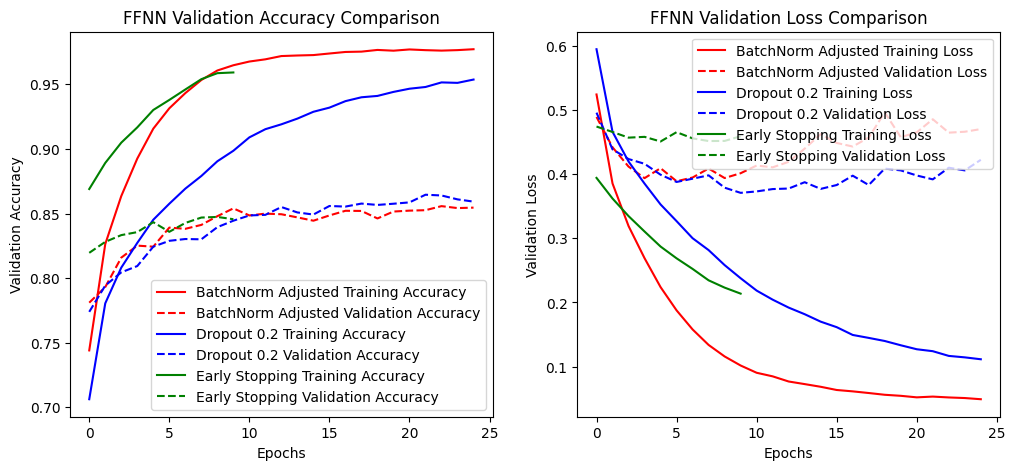

In [52]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
colors = ['r', 'b', 'g']
labels = ['BatchNorm Adjusted Training Accuracy', 'BatchNorm Adjusted Validation Accuracy', 'Dropout 0.2 Training Accuracy', 'Dropout 0.2 Validation Accuracy', 'Early Stopping Training Accuracy', 'Early Stopping Validation Accuracy']
for i, history in enumerate([history_ffnn_batchNorm_adjusted, history_ffnn_dropout_02, history_ffnn_l1_l2_early_stopping]):
    plt.plot(history.history['accuracy'], color=colors[i], label=labels[i * 2])
    plt.plot(history.history['val_accuracy'], '--', color=colors[i], label=labels[i * 2 + 1])
plt.title('FFNN Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
labels_loss = ['BatchNorm Adjusted Training Loss', 'BatchNorm Adjusted Validation Loss', 'Dropout 0.2 Training Loss', 'Dropout 0.2 Validation Loss', 'Early Stopping Training Loss', 'Early Stopping Validation Loss']
for i, history in enumerate([history_ffnn_batchNorm_adjusted, history_ffnn_dropout_02, history_ffnn_l1_l2_early_stopping]):
    plt.plot(history.history['loss'], color=colors[i], label=labels_loss[i * 2])
    plt.plot(history.history['val_loss'], '--', color=colors[i], label=labels_loss[i * 2 + 1])
plt.title('FFNN Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

Applying L1 and L2 regularization along with Early Stopping has resulted in a model that converges quickly and maintains a low validation loss, indicating effective generalization to unseen data. The training accuracy is high, and the validation accuracy is comparable to previous models, but with reduced overfitting as evidenced by the stable validation loss.

### 1.2.4 Optimization

We will compare four optimizers:
- SGD (Stochastic Gradient Descent): A simple and widely used optimizer that updates the model weights based on the gradient of the loss function with respect to the weights. It can be slow to converge and may get stuck in local minima.
- RMSprop: An adaptive learning rate optimizer that adjusts the learning rate for each weight based on the average of recent gradients. It is well-suited for non-stationary objectives and can converge faster than SGD.
- Adam (Adaptive Moment Estimation): Combines the benefits of both RMSprop and Momentum. It computes adaptive learning rates for each parameter and maintains a moving average of both the gradients and the squared gradients. Adam is generally more efficient and requires less tuning of hyperparameters compared to SGD and RMSprop.
- Adagrad: An adaptive learning rate optimizer that adjusts the learning rate for each weight based on the historical sum of squared gradients. It is particularly effective for sparse data and can converge faster than SGD.

> We will also add learning rate decay to the optimizers to help them converge better. The idea behind learning rate decay is to gradually reduce the learning rate as training progresses. This allows the model to make larger updates to the weights in the initial stages of training when it is far from the optimal solution, and smaller updates as it gets closer to convergence. By reducing the learning rate over time, we can help the model to fine-tune its weights and avoid overshooting the optimal solution.

> Using Adam is practically a default choice for many deep learning tasks due to its efficiency and effectiveness across a wide range of problems.

In [49]:
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Adagrad
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    if epoch > 10:
        lr = lr * np.exp(-0.1)
    return lr

optimizers = {
    'SGD': SGD(learning_rate=0.01),
    'RMSprop': RMSprop(learning_rate=0.001),
    'Adam': Adam(learning_rate=0.001),
    'Adagrad': Adagrad(learning_rate=0.01)
}

histories = {}

for name, optimizer in optimizers.items():
    print(f'Training with {name} optimizer...')
    model = Sequential()
    model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True))
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer='glorot_uniform'))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_initializer='glorot_uniform'))
    model.add(BatchNormalization())
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True, mode='min')
    lr_scheduler = LearningRateScheduler(lr_schedule, verbose=1)

    history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), batch_size=128, callbacks=[early_stopping, lr_scheduler])
    histories[name] = history

Training with SGD optimizer...

Epoch 1: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 1/50


/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7417 - loss: 0.6105 - val_accuracy: 0.7848 - val_loss: 0.5747 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 2/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8231 - loss: 0.4731 - val_accuracy: 0.8075 - val_loss: 0.4989 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 3/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8489 - loss: 0.4229 - val_accuracy: 0.8053 - val_loss: 0.4885 - learning_rate: 0.0100

Epoch 4: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 4/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8711 - loss: 0.3863 - val_accuracy: 0.8276 - val_loss: 0.4620 - learning_rate: 0.0100

Epoch 5: LearningRateScheduler setting learning rate to 0.009999999776482582.
Epoch 5/50
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8911 - loss: 0.3

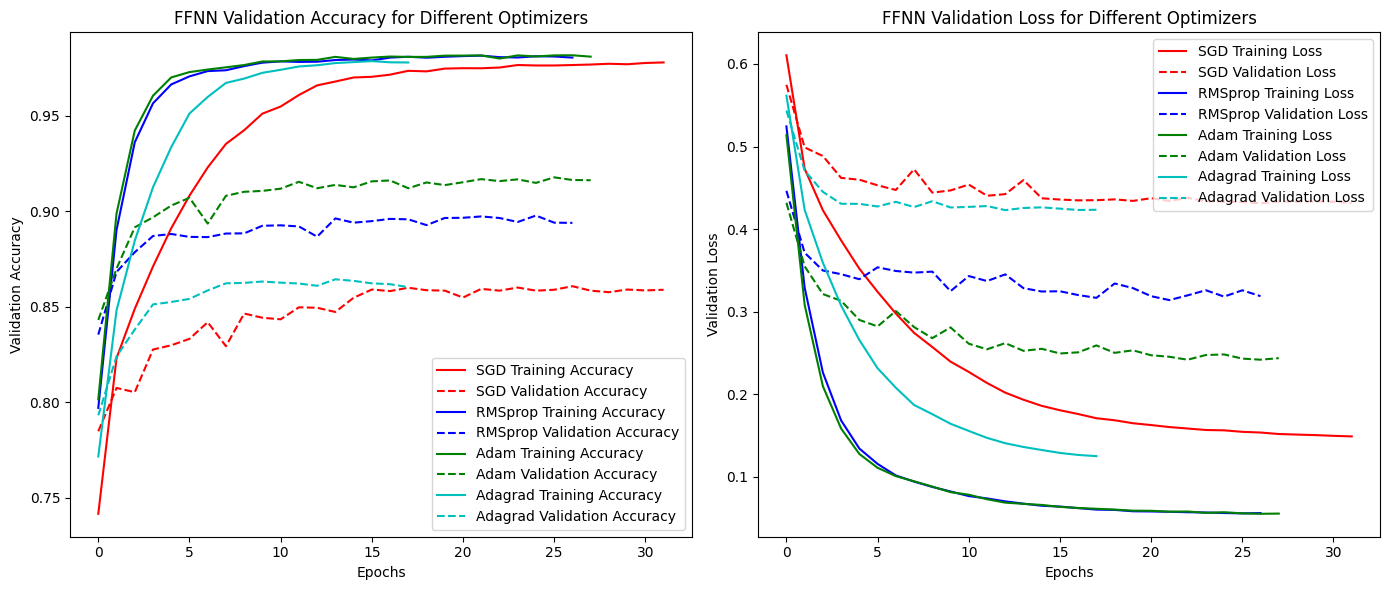

In [51]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
colors = ['r', 'b', 'g', 'c']
labels = ['SGD Training Accuracy', 'SGD Validation Accuracy', 'RMSprop Training Accuracy', 'RMSprop Validation Accuracy', 'Adam Training Accuracy', 'Adam Validation Accuracy', 'Adagrad Training Accuracy', 'Adagrad Validation Accuracy']
for i, (name, history) in enumerate(histories.items()):
    plt.plot(history.history['accuracy'], color=colors[i], label=labels[i * 2])
    plt.plot(history.history['val_accuracy'], '--', color=colors[i], label=labels[i * 2 + 1])
plt.title('FFNN Validation Accuracy for Different Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
labels_loss = ['SGD Training Loss', 'SGD Validation Loss', 'RMSprop Training Loss', 'RMSprop Validation Loss', 'Adam Training Loss', 'Adam Validation Loss', 'Adagrad Training Loss', 'Adagrad Validation Loss']
for i, (name, history) in enumerate(histories.items()):
    plt.plot(history.history['loss'], color=colors[i], label=labels_loss[i * 2])
    plt.plot(history.history['val_loss'], '--', color=colors[i], label=labels_loss[i * 2 + 1])
plt.title('FFNN Validation Loss for Different Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

Adam optimizer is the clear winner here, with the highest validation accuracy and less overfitting compared to the other optimizers. Same for validation loss. The second closest is RMSprop, which is also an adaptive learning rate optimizer. Adam also converges faster than the other optimizers with early stop at around 15 epochs.

## 1.3 Final Model and Evaluation
In this section, we will summarize the findings from the hyperparameter tuning and optimization techniques applied to the FFNN model for sentiment analysis on the Twitter dataset. The final model configuration will be presented along with its performance metrics on the test set.

In [62]:
df_test_size = int(len(validation_data) * 0.5)
df_test = validation_data.sample(n=df_test_size, random_state=42)
df_test = df_test[df_test['label'].isin(['Positive', 'Negative'])]

sequences_test = tokenizer.texts_to_sequences(df_test['clean_text'])
X_test = pad_sequences(sequences_test, maxlen=100, padding='post')
X_test = X_test.astype('float32')
y_test = df_test['label'].map({'Positive': 1, 'Negative': 0}).values.astype('float32')

In [70]:
loss_ffnn, accuracy_ffnn = model_ffnn.evaluate(X_test, y_test)

model_ffnn_best = Sequential()
model_ffnn_best.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, weights=[embedding_matrix], input_length=100, trainable=True))
model_ffnn_best.add(Flatten())
model_ffnn_best.add(Dense(128, activation='relu', kernel_initializer='glorot_uniform'))
model_ffnn_best.add(BatchNormalization())
model_ffnn_best.add(Dense(64, activation='relu', kernel_initializer='glorot_uniform'))
model_ffnn_best.add(BatchNormalization())
model_ffnn_best.add(Dense(1, activation='sigmoid', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)))

model_ffnn_best.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model_ffnn_best.fit(X_train, y_train, epochs=17, validation_data=(X_val, y_val), batch_size=128)

lost_ffnn_best, accuracy_ffnn_best = model_ffnn_best.evaluate(X_test, y_test)

print(f"FFNN Test Accuracy (initial model): {accuracy_ffnn:.4f}")
print(f"FFNN Test Accuracy (best model): {accuracy_ffnn_best:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8381 - loss: 0.4174 
Epoch 1/17


/home/javier/Documents/IA/IA learning/lab6/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8039 - loss: 0.5154 - val_accuracy: 0.8415 - val_loss: 0.4476
Epoch 2/17
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9049 - loss: 0.3000 - val_accuracy: 0.8471 - val_loss: 0.4029
Epoch 3/17
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9433 - loss: 0.2082 - val_accuracy: 0.8904 - val_loss: 0.3380
Epoch 4/17
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9620 - loss: 0.1558 - val_accuracy: 0.8991 - val_loss: 0.3042
Epoch 5/17
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9683 - loss: 0.1297 - val_accuracy: 0.9043 - val_loss: 0.2870
Epoch 6/17
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9720 - loss: 0.1119 - val_accuracy: 0.9035 - val_loss: 0.2815
Epoch 7/17
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9746 - loss: 0.0995 - val_accuracy: 0.9075 - val_loss: 0.2701
Epoch 8/17
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9765 - loss: 0.0899 - val_accuracy: 0.908

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


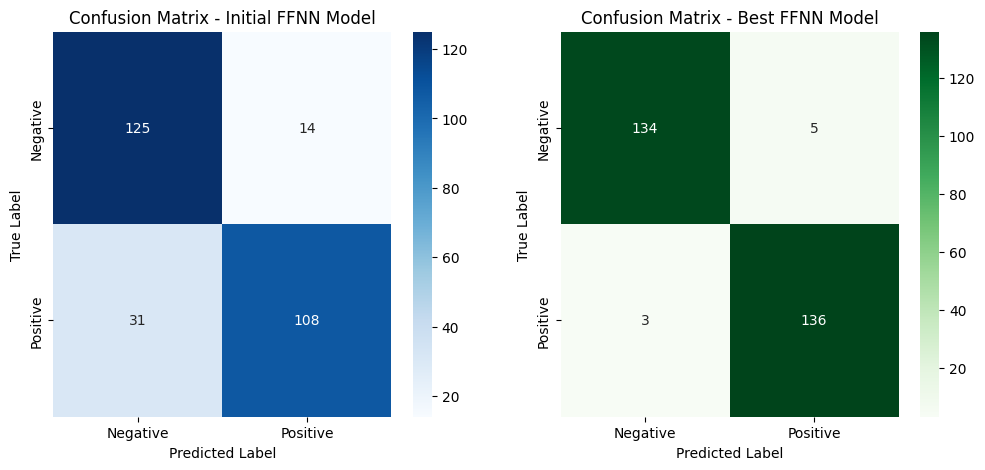

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_ffnn = (model_ffnn.predict(X_test) > 0.5).astype("int32")
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
y_pred_ffnn_best = (model_ffnn_best.predict(X_test) > 0.5).astype("int32")
cm_ffnn_best = confusion_matrix(y_test, y_pred_ffnn_best)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Initial FFNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.subplot(1, 2, 2)
sns.heatmap(cm_ffnn_best, annot=True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Best FFNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

We managed to improve the model significantly by applying various optimization techniques and hyperparameter tuning. The final model predicted the sentiment of tweets with a high degree of accuracy, only 3 false positives and 5 false negatives against 31 false positives and 14 false negatives from the initial model.